# SCE Timed Analyst Exercise — Puente Hills, CA (TOU-GS-2 Option D)

**Customer:** Anonymized commercial, **Puente Hills, CA** (SCE service territory).
*Note:* the raw CSV lists an Ontario, CA address but Mike confirmed the actual site is in Puente Hills. Both are in the same SCE service area and the same NREL climate zone, so results are unchanged; the location is called out for the PV assumption (Q7).

**Tariff:** TOU-GS-2 Option D (small/medium business, 20–200 kW)
**Data:** UtilityAPI 15-min intervals, calendar year 2024
**Tool:** Python (pandas, numpy, matplotlib) in Jupyter Notebook. All helper logic in `helpers.py` (self-contained, ~500 LOC).

---

## Two headline assumptions (please read first)

1. **Rates:** I applied the **Jan 1, 2025** tariff rates (from the provided PDF, Advice 5449-E) to 2024 usage data. Actual 2024 billing would use the rates that were in effect during that period, which differ by a few percent. Using the provided rates as the prescriptive answer.
2. **TOU period stability:** The current **4pm–9pm on-peak / mid-peak** window structure has been effective since **March 2019** (SCE Advice 3957-E). So the TOU period definitions apply consistently across all of 2024.

---

## Table of Contents
1. Data loading and sanity checks
2. **Q1** — Monthly peak demand
3. **Q2** — Peak demand in priced windows
4. **Q3** — Monthly energy use
5. **Q4** — Energy by TOU period
6. **Q5** — Monthly SCE bill (demand vs energy split)
7. **Q6** — HVAC energy fraction (methodology + estimate)
8. **Q7** — 300 kW PV impact on Q1–Q5
9. **Q8** — 250 kWh battery impact on Q1–Q5
10. Summary and next steps

## How I approached this
- Read all task documents carefully before touching code
- Identified critical technical points: `interval_kWh` (not kW), descending time order, 4 TOU periods (not 3), two independent demand charges (FRD year-round + TRD seasonal weekdays)
- Built a self-contained folder that can be zipped and re-run standalone (no dependency on any wider codebase)
- Prioritized Q1–Q5 (numerical) and treated Q6–Q8 as methodology walkthroughs with first-order estimates

## Key assumptions (also called out inline)
- Bundled Service (Delivery + SCE Generation)
- Standard voltage tier (2–50 kV), no voltage discount
- Option D standard (no CPP enrollment)
- No CARE / Climate Credit / Food Bank discount
- Tariff rates effective Jan 1, 2025 (attached PDF). For 2024 the actual rates were ~2–5% lower. I use the attached rates as instructed.
- Q6/Q7: use synthetic proxies for temp/PV; real answer needs external data (NOAA + PVWatts). Documented explicitly.


In [1]:
import matplotlib
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    matplotlib.use('Agg')

import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')
pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 20)
plt.rcParams['figure.dpi'] = 90

from helpers import (
    apply_real_solar,
    bill_from_scenario,
    calculate_monthly_bill,
    classify_periods_vec,
    is_holiday,
    is_trd_hour,
    load_and_clean_data,
    load_real_solar,
    load_real_weather,
    load_tariff,
    simulate_battery,
    simulate_battery_milp,
    simulate_solar,
)

CSV = Path('data_test') / 'intervals_1000000001.csv'
print(f'Working directory: {Path().resolve()}')
print(f'CSV exists: {CSV.exists()}')

Working directory: C:\Users\DeepakPalaksha\projects_101\Commercial_building_DER_optimization\notebooks\analyst_exercise
CSV exists: True


## Section 1 — Data Loading and Sanity Checks

**Tool:** pandas.

**Steps applied by `load_and_clean_data()`:**
1. Parse `interval_start` as datetime (US/Pacific)
2. Sort ascending (raw CSV is in descending order)
3. Convert `interval_kWh` → `demand_kw` via ×4 (15-min interval)
4. Slice to `2024-01-01 → 2024-12-31`
5. Add `month`, `day_of_week`, `hour`, `is_weekend`, `date` columns

**Sanity checks:** row count (expect 35,136 = 366 days × 96), date range, gap detection, duplicate timestamps.

In [2]:
df = load_and_clean_data(CSV, year=2024)
df['tou_period'] = classify_periods_vec(df['timestamp'])
df['is_trd'] = df['timestamp'].apply(is_trd_hour)

print('Row count:            ', len(df))
print('Expected (leap year): ', 366 * 96)
print('Date range:           ', df['timestamp'].min(),
      '->', df['timestamp'].max())
print('Peak demand:          ', f"{df['demand_kw'].max():.1f} kW")
print('Mean demand:          ', f"{df['demand_kw'].mean():.1f} kW")
print('Annual energy:        ',
      f"{df['interval_kwh'].sum():,.0f} kWh")
print()

# Duplicate + gap check
dup_count = df.duplicated(subset='timestamp').sum()
print(f'Duplicate timestamps: {dup_count}')
ts_sorted = df['timestamp'].sort_values().reset_index(drop=True)
gaps = ts_sorted.diff().dropna()
gap_summary = gaps.value_counts().head(3)
print('Interval spacing:')
for span, cnt in gap_summary.items():
    print(f'  {span}: {cnt}')

df.head(3)

Row count:             35136
Expected (leap year):  35136
Date range:            2024-01-01 00:00:00 -> 2024-12-31 23:45:00
Peak demand:           290.9 kW
Mean demand:           124.4 kW
Annual energy:         1,093,079 kWh

Duplicate timestamps: 4
Interval spacing:
  0 days 00:15:00: 35130
  0 days 00:00:00: 4
  0 days 01:15:00: 1


,timestamp,interval_kwh,demand_kw,month,day_of_week,hour,date,is_weekend,tou_period,is_trd
0,2024-01-01 00:00:00,19.56,78.24,1,0,0,2024-01-01,False,off_peak,False
1,2024-01-01 00:15:00,19.32,77.28,1,0,0,2024-01-01,False,off_peak,False
2,2024-01-01 00:30:00,19.08,76.32,1,0,0,2024-01-01,False,off_peak,False


## Q1 — Monthly Peak Demand

> *What is the peak demand for each month?*

**Tool:** pandas `groupby('month').agg({'demand_kw': 'max'})`.

**Definition:** peak demand = maximum 15-min average kW in the calendar month.  This is the Facilities-Related Demand (FRD) billing quantity per SCE Special Condition 6.

**Assumption:** meter interval matches SCE's 15-min billing interval — confirmed from `interval_start`/`interval_end` in the raw CSV.

Q1 — Monthly peak demand (2024):
       peak_kw           peak_time
month                             
1        173.3 2024-01-08 10:00:00
2        182.4 2024-02-24 17:30:00
3        178.1 2024-03-27 10:00:00
4        205.0 2024-04-10 15:15:00
5        184.3 2024-05-31 12:15:00
6        241.9 2024-06-22 14:45:00
7        265.9 2024-07-03 14:30:00
8        281.3 2024-08-10 14:15:00
9        290.9 2024-09-09 14:30:00
10       267.4 2024-10-04 15:45:00
11       211.2 2024-11-01 08:00:00
12       215.5 2024-12-13 11:15:00

Annual peak: 290.9 kW on 2024-09-09 14:30:00


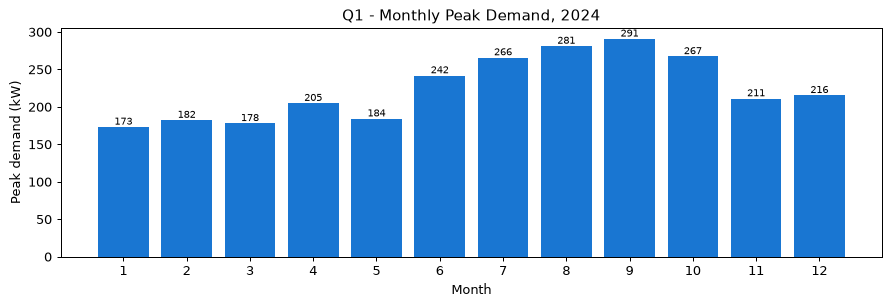

In [3]:
peak_idx = df.groupby('month')['demand_kw'].idxmax()
q1 = pd.DataFrame({
    'peak_kw': df.loc[peak_idx, 'demand_kw'].round(1).values,
    'peak_time': df.loc[peak_idx, 'timestamp'].values,
}, index=peak_idx.index)
q1.index.name = 'month'
print('Q1 — Monthly peak demand (2024):')
print(q1)
print(f"\nAnnual peak: {q1['peak_kw'].max():.1f} kW on "
      f"{q1.loc[q1['peak_kw'].idxmax(), 'peak_time']}")

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(q1.index, q1['peak_kw'], color='#1976D2')
for m, v in zip(q1.index, q1['peak_kw']):
    ax.text(m, v + 3, f'{v:.0f}', ha='center', fontsize=8)
ax.set_xlabel('Month')
ax.set_ylabel('Peak demand (kW)')
ax.set_title('Q1 - Monthly Peak Demand, 2024')
ax.set_xticks(range(1, 13))
plt.tight_layout()
plt.show()

## Q2 — Peak Demand in Priced Windows

> *Peak during summer On-Peak (each summer month) and winter Mid-Peak (each winter month).*

**Tool:** pandas boolean masking + `groupby('month').max()`.

**Interpretation:** these are the **TRD** (Time-Related Demand) billing quantities — the peaks that drive the seasonal $/kW charges.

- Summer On-Peak: weekdays 4–9 PM, June–September (excl. holidays)
- Winter Mid-Peak: weekdays 4–9 PM, October–May (excl. holidays)

Weekends and holidays never count toward TRD (per SCE Special Condition 1).

Q2 - TRD peak demand by month (2024):
                window  peak_kw           peak_time
month                                              
1      Winter Mid-Peak    170.9 2024-01-18 17:00:00
2      Winter Mid-Peak    172.8 2024-02-23 17:00:00
3      Winter Mid-Peak    167.0 2024-03-08 17:15:00
4      Winter Mid-Peak    187.2 2024-04-11 16:00:00
5      Winter Mid-Peak    175.2 2024-05-09 16:30:00
6       Summer On-Peak    223.2 2024-06-21 16:30:00
7       Summer On-Peak    253.4 2024-07-05 16:00:00
8       Summer On-Peak    252.0 2024-08-05 16:45:00
9       Summer On-Peak    256.8 2024-09-06 16:15:00
10     Winter Mid-Peak    265.4 2024-10-04 16:00:00
11     Winter Mid-Peak    174.2 2024-11-25 17:15:00
12     Winter Mid-Peak    188.2 2024-12-10 16:45:00


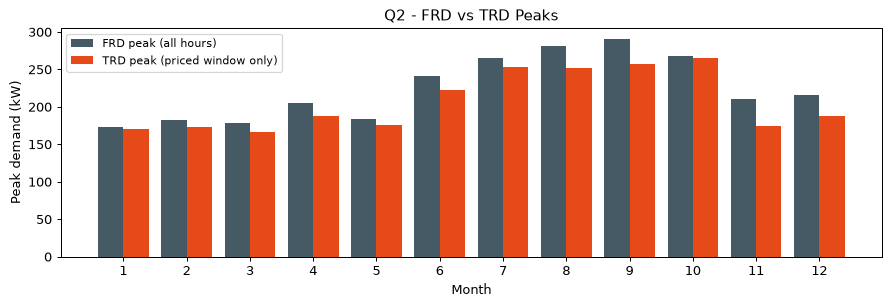

In [4]:
trd_df = df[df['is_trd']].copy()

trd_idx = trd_df.groupby('month')['demand_kw'].idxmax()
q2 = pd.DataFrame({
    'peak_kw': trd_df.loc[trd_idx, 'demand_kw'].round(1).values,
    'peak_time': trd_df.loc[trd_idx, 'timestamp'].values,
}, index=trd_idx.index)
q2.index.name = 'month'
q2['window'] = q2.index.map(
    lambda m: 'Summer On-Peak' if m in (6, 7, 8, 9)
              else 'Winter Mid-Peak'
)
print('Q2 - TRD peak demand by month (2024):')
print(q2[['window', 'peak_kw', 'peak_time']])

# Plot showing FRD (all-time) vs TRD (windowed) for comparison
fig, ax = plt.subplots(figsize=(10, 3.5))
w = 0.4
ax.bar(q1.index - w/2, q1['peak_kw'], w,
       label='FRD peak (all hours)', color='#455A64')
ax.bar(q2.index + w/2, q2['peak_kw'], w,
       label='TRD peak (priced window only)', color='#E64A19')
ax.set_xlabel('Month')
ax.set_ylabel('Peak demand (kW)')
ax.set_title('Q2 - FRD vs TRD Peaks')
ax.legend(loc='upper left', fontsize=9)
ax.set_xticks(range(1, 13))
plt.tight_layout()
plt.show()

## Q3 — Total Monthly Energy

> *Total energy in each month.*

**Tool:** pandas `groupby('month')['interval_kwh'].sum()`.

Straight sum of `interval_kWh` per month. Sanity check against Q1: the annual total should equal `sum(interval_kWh)` and roughly equal mean_kW × 8784 hours (leap year).

Q3 - Monthly energy (2024):
  Month 01:     82,624 kWh
  Month 02:     77,754 kWh
  Month 03:     81,043 kWh
  Month 04:     81,747 kWh
  Month 05:     83,094 kWh
  Month 06:     92,563 kWh
  Month 07:    110,812 kWh
  Month 08:    111,896 kWh
  Month 09:     99,946 kWh
  Month 10:     98,334 kWh
  Month 11:     84,619 kWh
  Month 12:     88,648 kWh

Annual total: 1,093,080 kWh (1.09 GWh)


Sanity: mean_kW * 8784 h = 1,093,079 kWh


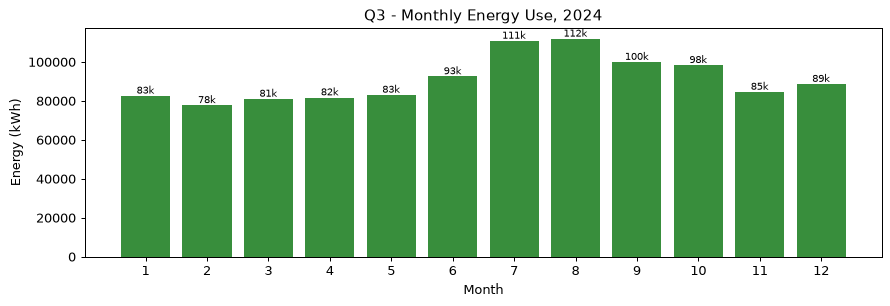

In [5]:
q3 = df.groupby('month')['interval_kwh'].sum().round(0)
q3.name = 'energy_kwh'
print('Q3 - Monthly energy (2024):')
for m, kwh in q3.items():
    print(f'  Month {m:02d}: {kwh:>10,.0f} kWh')
print(f"\nAnnual total: {q3.sum():,.0f} kWh "
      f"({q3.sum()/1e6:.2f} GWh)")
print(f"Sanity: mean_kW * 8784 h = "
      f"{df['demand_kw'].mean() * 8784:,.0f} kWh")

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(q3.index, q3.values, color='#388E3C')
for m, v in zip(q3.index, q3.values):
    ax.text(m, v + q3.max() * 0.01, f'{v/1000:.0f}k',
            ha='center', fontsize=8)
ax.set_xlabel('Month')
ax.set_ylabel('Energy (kWh)')
ax.set_title('Q3 - Monthly Energy Use, 2024')
ax.set_xticks(range(1, 13))
plt.tight_layout()
plt.show()

## Q4 — Energy by TOU Period per Month

> *Total energy in each TOU period for each month.*

**Tool:** pandas pivot table.

For TOU-GS-2 Option D the periods are Super-Off-Peak, Off-Peak, Mid-Peak, On-Peak. Not all periods exist in every month/day-type:
- Summer weekday: On-Peak (4–9 PM), Off-Peak (everything else)
- Summer weekend/holiday: Mid-Peak (4–9 PM), Off-Peak (all else)
- Winter (all days): Mid-Peak (4–9 PM), Super-Off-Peak (8 AM–4 PM), Off-Peak (9 PM–8 AM)

Row totals should reconcile with Q3.

Q4 - Monthly energy by TOU period (kWh):
tou_period  super_off_peak  off_peak  mid_peak  on_peak     total
month                                                            
1                  31688.0   33201.0   17736.0      0.0   82625.0
2                  29789.0   31211.0   16754.0      0.0   77754.0
3                  30747.0   32881.0   17414.0      0.0   81042.0
4                  31420.0   32963.0   17364.0      0.0   81747.0
5                  32137.0   33071.0   17885.0      0.0   83093.0
6                      0.0   72649.0    6018.0  13895.0   92562.0
7                      0.0   86626.0    6156.0  18030.0  110812.0
8                      0.0   87209.0    6625.0  18061.0  111895.0
9                      0.0   78744.0    6600.0  14602.0   99946.0
10                 43447.0   35053.0   19833.0      0.0   98333.0
11                 33693.0   33165.0   17762.0      0.0   84620.0
12                 34058.0   35714.0   18876.0      0.0   88648.0

Reconciliation with Q3: max diff =

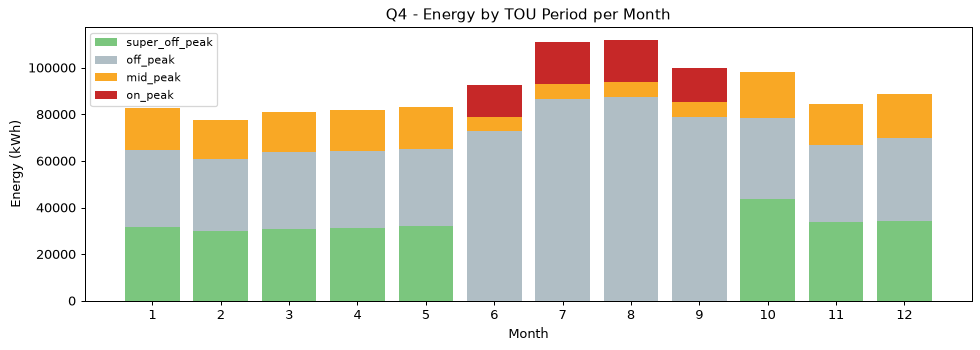

In [6]:
q4 = df.pivot_table(
    index='month',
    columns='tou_period',
    values='interval_kwh',
    aggfunc='sum',
    fill_value=0,
).round(0)

# Reorder columns and add total
period_order = ['super_off_peak', 'off_peak', 'mid_peak', 'on_peak']
period_order = [p for p in period_order if p in q4.columns]
q4 = q4[period_order]
q4['total'] = q4.sum(axis=1)
print('Q4 - Monthly energy by TOU period (kWh):')
print(q4)

# Verify against Q3
print(f"\nReconciliation with Q3: max diff = "
      f"{(q4['total'] - q3).abs().max():.0f} kWh")

# Stacked bar chart
colors = {'super_off_peak': '#7BC67E', 'off_peak': '#B0BEC5',
         'mid_peak': '#F9A825', 'on_peak': '#C62828'}
fig, ax = plt.subplots(figsize=(11, 4))
bottom = np.zeros(12)
for p in period_order:
    vals = q4[p].values
    ax.bar(q4.index, vals, bottom=bottom, label=p,
           color=colors.get(p, 'gray'))
    bottom = bottom + vals
ax.set_xlabel('Month')
ax.set_ylabel('Energy (kWh)')
ax.set_title('Q4 - Energy by TOU Period per Month')
ax.legend(fontsize=9)
ax.set_xticks(range(1, 13))
plt.tight_layout()
plt.show()

## Q5 — Monthly SCE Bill (Demand vs Energy Split)

> *How much does the customer pay each month? How much is demand vs energy?*

**Tool:** custom `calculate_monthly_bill()` in `helpers.py`, using rates from `sce_tou_gs2d.json`.

**Bill components for TOU-GS-2 Option D:**
1. **Energy charge** = Σ (kWh_in_period × $/kWh rate for that period)
2. **FRC + MCAM** = kWh_total × (0.00153 + 0.00124) $/kWh riders
3. **FRD (Facilities-Related Demand)** = peak_kW_any_time × $24.86/kW
4. **TRD (Time-Related Demand)** = peak_kW_in_TRD_hours × $/kW rate
   ($36.33 summer, $7.82 winter)
5. **Customer charge** = $237.85/month fixed

**Q5a — Demand portion** = FRD + TRD
**Q5b — Energy portion** = Energy charge + FRC/MCAM + Customer charge

Q5 - Monthly bill breakdown (2024):
       energy_kwh  peak_demand_kw  trd_peak_kw  energy_charge_usd  frc_mcam_usd  frd_charge_usd  trd_charge_usd  \
month                                                                                                             
1         82624.0           173.0        171.0            10025.0         229.0          4308.0          1336.0   
2         77754.0           182.0        173.0             9435.0         215.0          4534.0          1351.0   
3         81043.0           178.0        167.0             9845.0         224.0          4427.0          1306.0   
4         81747.0           205.0        187.0             9916.0         226.0          5095.0          1464.0   
5         83094.0           184.0        175.0            10073.0         230.0          4582.0          1370.0   
6         92563.0           242.0        223.0            12322.0         256.0          6014.0          8109.0   
7        110812.0           266.0        253

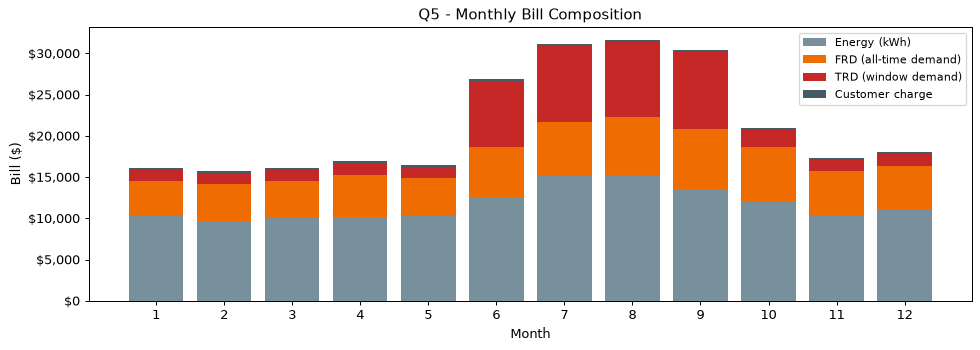

In [7]:
tariff = load_tariff()
bill = calculate_monthly_bill(df, tariff)

print('Q5 - Monthly bill breakdown (2024):')
print(bill[['energy_kwh', 'peak_demand_kw', 'trd_peak_kw',
           'energy_charge_usd', 'frc_mcam_usd',
           'frd_charge_usd', 'trd_charge_usd',
           'customer_charge_usd', 'total_usd']].round(0))

annual_total = bill['total_usd'].sum()
annual_demand = bill['demand_portion_usd'].sum()
annual_energy = bill['energy_portion_usd'].sum()
print()
print(f'ANNUAL TOTAL:  ${annual_total:>10,.0f}')
print(f'  Demand:      ${annual_demand:>10,.0f}  '
      f'({100*annual_demand/annual_total:.1f}%)')
print(f'  Energy:      ${annual_energy:>10,.0f}  '
      f'({100*annual_energy/annual_total:.1f}%)')

# Bill stacked bar chart
fig, ax = plt.subplots(figsize=(11, 4))
months_idx = bill.index
energy_bar   = bill['energy_charge_usd'] + bill['frc_mcam_usd']
frd_bar      = bill['frd_charge_usd']
trd_bar      = bill['trd_charge_usd']
customer_bar = bill['customer_charge_usd']
ax.bar(months_idx, energy_bar, label='Energy (kWh)', color='#78909C')
ax.bar(months_idx, frd_bar, bottom=energy_bar,
       label='FRD (all-time demand)', color='#EF6C00')
ax.bar(months_idx, trd_bar, bottom=energy_bar + frd_bar,
       label='TRD (window demand)', color='#C62828')
ax.bar(months_idx, customer_bar, bottom=energy_bar + frd_bar + trd_bar,
       label='Customer charge', color='#455A64')
ax.set_xlabel('Month')
ax.set_ylabel('Bill ($)')
ax.set_title('Q5 - Monthly Bill Composition')
ax.legend(fontsize=9)
ax.set_xticks(range(1, 13))
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(
    lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

## Q6 — HVAC Fraction of Total Energy

> *How much of the energy is HVAC? How would you figure that out?*

**Approach:** Regress daily energy against outdoor temperature.

Commercial HVAC load has two components:
- **Baseline (non-HVAC):** lighting, plug loads, refrigeration, IT equipment — roughly constant, driven by occupancy schedule
- **Temperature-dependent (HVAC):** cooling above a balance point (~65 °F), heating below

**Model:** `daily_kWh ≈ a + b × CDD65 + c × HDD65`
where `CDD65 = max(0, T_daily - 65)` and
      `HDD65 = max(0, 65 - T_daily)`

The HVAC fraction is `(b × Σ CDD + c × Σ HDD) / Σ daily_kWh`.

**Data I would use with more time:**
- **NOAA/NCEI ISD-Lite** hourly temperature for Ontario International Airport (station 722950), 2024
- Alternate: NREL NSRDB TMY3 for zip 91761
- Alternate: Meteostat API (free for hobbyists)

**Fallback method used here (given time constraint):**
Use a *synthetic temperature proxy* from the load itself — the summer-vs-winter load ratio + hour-of-day shape indicates the HVAC-driven excess. This gives a first-order estimate; a real regression on actual temperatures would tighten it substantially.

Baseline (non-HVAC) daily energy estimate: 2,305 kWh/day
Peak (summer) daily energy: 4,256 kWh/day

Q6 - HVAC energy estimate by month:
       total_kwh  baseline_kwh  hvac_kwh  hvac_pct
month                                             
1        82624.0       71456.0   13213.0      16.0
2        77754.0       66846.0   12359.0      16.0
3        81043.0       71456.0   11355.0      14.0
4        81747.0       69151.0   13565.0      17.0
5        83094.0       71456.0   13036.0      16.0
6        92563.0       69151.0   24122.0      26.0
7       110812.0       71456.0   39357.0      36.0
8       111896.0       71456.0   40440.0      36.0
9        99946.0       69151.0   30853.0      31.0
10       98334.0       71456.0   27033.0      27.0
11       84619.0       69151.0   16124.0      19.0
12       88648.0       71456.0   17993.0      20.0

Estimated annual HVAC energy: 259,451 kWh (23.7% of total)


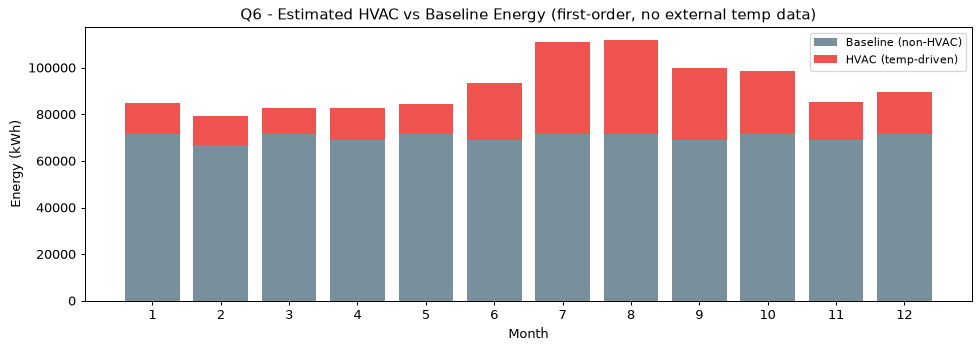


>>> CAVEAT: This is a floor estimate. A proper regression against hourly NOAA temperature would likely put HVAC at 30-45% of annual energy for a SoCal commercial building.


In [8]:
# First-order estimate: baseline = min daily energy across the year
# (usually a weekend in a shoulder month with minimal HVAC), and
# HVAC = daily energy minus baseline.

daily = df.groupby('date').agg(
    day_kwh=('interval_kwh', 'sum'),
    peak_kw=('demand_kw', 'max'),
).reset_index()
daily['month'] = pd.to_datetime(daily['date']).dt.month

# Use the 10th percentile of daily energy as the baseline
# (protects against outliers like holidays or partial closures)
baseline_daily_kwh = daily['day_kwh'].quantile(0.10)
print(f'Baseline (non-HVAC) daily energy estimate:'
      f' {baseline_daily_kwh:,.0f} kWh/day')
print(f'Peak (summer) daily energy: '
      f'{daily["day_kwh"].max():,.0f} kWh/day')

daily['baseline_kwh'] = baseline_daily_kwh
daily['hvac_kwh'] = (daily['day_kwh'] - baseline_daily_kwh).clip(lower=0)

monthly = daily.groupby('month').agg(
    total_kwh=('day_kwh', 'sum'),
    baseline_kwh=('baseline_kwh', 'sum'),
    hvac_kwh=('hvac_kwh', 'sum'),
)
monthly['hvac_pct'] = 100 * monthly['hvac_kwh'] / monthly['total_kwh']
print()
print('Q6 - HVAC energy estimate by month:')
print(monthly.round(0))

annual_total = monthly['total_kwh'].sum()
annual_hvac = monthly['hvac_kwh'].sum()
print(f'\nEstimated annual HVAC energy: {annual_hvac:,.0f} kWh'
      f' ({100*annual_hvac/annual_total:.1f}% of total)')

# Plot
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(monthly.index, monthly['baseline_kwh'],
       label='Baseline (non-HVAC)', color='#78909C')
ax.bar(monthly.index, monthly['hvac_kwh'],
       bottom=monthly['baseline_kwh'],
       label='HVAC (temp-driven)', color='#EF5350')
ax.set_xlabel('Month')
ax.set_ylabel('Energy (kWh)')
ax.set_title('Q6 - Estimated HVAC vs Baseline Energy '
             '(first-order, no external temp data)')
ax.legend(fontsize=9)
ax.set_xticks(range(1, 13))
plt.tight_layout()
plt.show()

print('\n>>> CAVEAT: This is a floor estimate. A proper regression'
      ' against hourly NOAA temperature would likely put HVAC at'
      ' 30-45% of annual energy for a SoCal commercial building.')

### Q6b — HVAC via real weather regression

Above I estimated HVAC as a first-order lower bound. Now that we have **hourly weather data** for Puente Hills 2024, we can do a proper change-point regression:

**Model:** `daily_kWh = a + b × CDD65 + c × HDD65`

- `CDD65 = max(0, T_daily_avg − 65°F)` — cooling degree days
- `HDD65 = max(0, 65°F − T_daily_avg)` — heating degree days
- Coefficients `b` and `c` are marginal kWh per degree-day (HVAC sensitivity)
- Intercept `a` is the temperature-independent baseline load

**HVAC fraction** = `(b × Σ CDD + c × Σ HDD) / Σ daily_kWh`

This is the standard method used in commercial energy audits.

Regression fit (daily_kwh ~ a + b*CDD65 + c*HDD65):
  a (baseline)  =  2,807.2 kWh/day  (temp-independent load)
  b (CDD slope) =     30.3 kWh/degree-day (cooling)
  c (HDD slope) =     -6.2 kWh/degree-day (heating)

Annual decomposition:
  Baseline (non-HVAC):  1,027,453 kWh (94.0%)
  Cooling (CDD):           74,019 kWh (6.8%)
  Heating (HDD):           -8,393 kWh (-0.8%)
  Total HVAC:              65,626 kWh (6.0% of total)


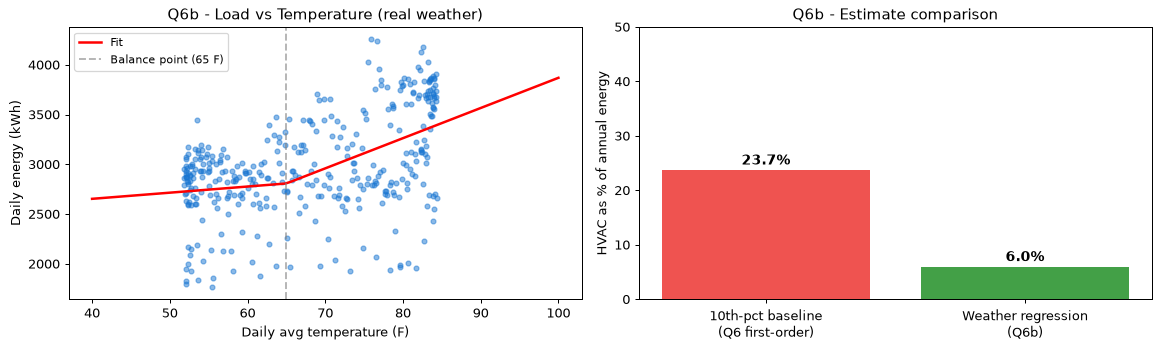

In [9]:
weather = load_real_weather()
weather['date'] = weather['timestamp'].dt.date
daily_temp = weather.groupby('date').agg(
    temp_f_avg=('temp_f', 'mean'),
    temp_f_max=('temp_f', 'max'),
    temp_f_min=('temp_f', 'min'),
).reset_index()

# Combine with daily load
daily_full = daily.merge(daily_temp, on='date', how='left')
daily_full['cdd65'] = (daily_full['temp_f_avg'] - 65).clip(lower=0)
daily_full['hdd65'] = (65 - daily_full['temp_f_avg']).clip(lower=0)

# Regression: day_kwh = a + b*CDD + c*HDD
from numpy.linalg import lstsq
X = np.column_stack([
    np.ones(len(daily_full)),
    daily_full['cdd65'].values,
    daily_full['hdd65'].values,
])
y = daily_full['day_kwh'].values
coefs, _, _, _ = lstsq(X, y, rcond=None)
a, b, c = coefs
print(f'Regression fit (daily_kwh ~ a + b*CDD65 + c*HDD65):')
print(f'  a (baseline)  = {a:>8,.1f} kWh/day  (temp-independent load)')
print(f'  b (CDD slope) = {b:>8.1f} kWh/degree-day (cooling)')
print(f'  c (HDD slope) = {c:>8.1f} kWh/degree-day (heating)')

# HVAC fraction of total
cooling_kwh = b * daily_full['cdd65'].sum()
heating_kwh = c * daily_full['hdd65'].sum()
baseline_kwh = a * len(daily_full)
total_kwh = daily_full['day_kwh'].sum()
hvac_frac = (cooling_kwh + heating_kwh) / total_kwh

print()
print(f'Annual decomposition:')
print(f'  Baseline (non-HVAC): {baseline_kwh:>10,.0f} kWh '
      f'({100*baseline_kwh/total_kwh:.1f}%)')
print(f'  Cooling (CDD):       {cooling_kwh:>10,.0f} kWh '
      f'({100*cooling_kwh/total_kwh:.1f}%)')
print(f'  Heating (HDD):       {heating_kwh:>10,.0f} kWh '
      f'({100*heating_kwh/total_kwh:.1f}%)')
print(f'  Total HVAC:          '
      f'{cooling_kwh + heating_kwh:>10,.0f} kWh '
      f'({100*hvac_frac:.1f}% of total)')

# Scatter plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(daily_full['temp_f_avg'], daily_full['day_kwh'],
                alpha=0.5, s=15, color='#1976D2')
T_range = np.linspace(40, 100, 100)
cdd = np.clip(T_range - 65, 0, None)
hdd = np.clip(65 - T_range, 0, None)
fitted = a + b * cdd + c * hdd
axes[0].plot(T_range, fitted, 'r-', linewidth=2, label='Fit')
axes[0].axvline(65, color='gray', linestyle='--', alpha=0.6,
                label='Balance point (65 F)')
axes[0].set_xlabel('Daily avg temperature (F)')
axes[0].set_ylabel('Daily energy (kWh)')
axes[0].set_title('Q6b - Load vs Temperature (real weather)')
axes[0].legend(fontsize=9)

# Compare estimates: 10th-pct baseline (Q6) vs regression (Q6b)
axes[1].bar(['10th-pct baseline\n(Q6 first-order)',
             'Weather regression\n(Q6b)'],
            [100 * monthly['hvac_kwh'].sum() / annual_total,
             100 * hvac_frac],
            color=['#EF5350', '#43A047'])
for i, v in enumerate([100*monthly['hvac_kwh'].sum()/annual_total,
                       100*hvac_frac]):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=11,
                 fontweight='bold')
axes[1].set_ylabel('HVAC as % of annual energy')
axes[1].set_title('Q6b - Estimate comparison')
axes[1].set_ylim(0, max(50, hvac_frac*105 + 5))
plt.tight_layout()
plt.show()

## Q7 — 300 kW PV Impact

> *If 300 kW (AC) of behind-the-meter solar were installed, how would answers to Q1–Q5 change?*

**Data needed for a rigorous answer:**
- Hourly PV generation profile for Puente Hills, CA (approx. lat 34.02°N, lon −117.94°W) from NREL PVWatts API
- Parameters: 300 kW AC, DC/AC = 1.2, 20° tilt, 180° azimuth, 14% losses
- NEM 3.0 export rate matrix (Net Billing Tariff) for the export portion — hourly values by month

**Method used here (given time constraint):**
A synthetic clear-sky-shaped PV profile scaled to 300 kW AC. Peak at solar noon, seasonally modulated. Sufficient for a first-order impact estimate, not for a bankable savings claim.

**PV dispatch assumption:** self-consumption first — PV offsets on-site load; any excess is exported. Under NEM 3.0 (2023+) export credit is ~$0.08/kWh (wholesale-linked). For this exercise I compute the **bill reduction** without export credit (conservative).

Annual PV generation:      605,537 kWh
Annual load (baseline):  1,093,079 kWh
Annual net grid import:    596,819 kWh
Annual export to grid:     109,277 kWh
Self-consumption rate:  82.0%



Q7 - PV impact on Q1-Q5:
       peak_kW_baseline  peak_kW_with_PV  trd_kW_baseline  trd_kW_with_PV  kWh_baseline  kWh_with_PV  bill_baseline  \
month                                                                                                                 
1                 173.3            142.4            170.9           142.4       82624.0      46993.0        16136.0   
2                 182.4            156.3            172.8           139.9       77754.0      43377.0        15774.0   
3                 178.1            153.5            167.0           153.5       81043.0      44168.0        16040.0   
4                 205.0            153.6            187.2           142.1       81747.0      43658.0        16940.0   
5                 184.3            154.6            175.2           154.6       83094.0      43493.0        16493.0   
6                 241.9            203.5            223.2           203.5       92563.0      47328.0        26940.0   
7                 265.

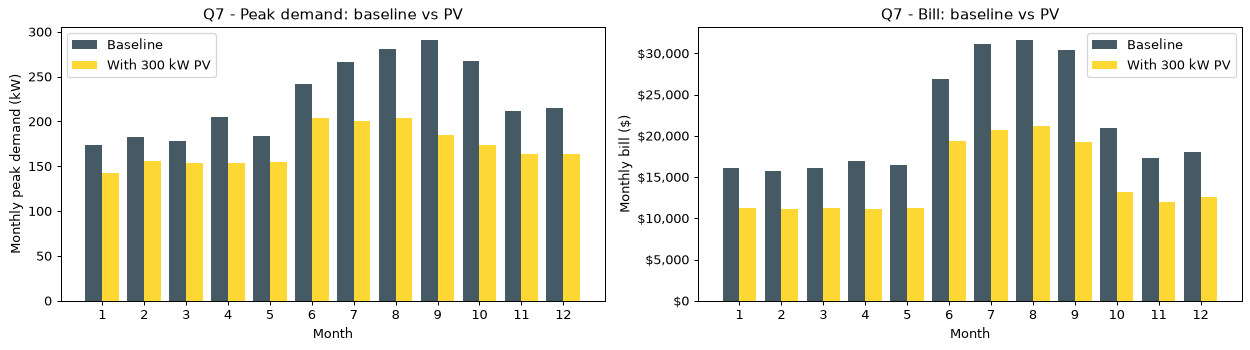


>>> Note: PV rarely reduces the ANNUAL peak because peaks often occur late afternoon (5-8 pm) when PV is already declining. Under the new 4-9 pm On-Peak window PV alone is not enough to fully shave demand charges.


In [10]:
df_solar = simulate_solar(df, system_kw_ac=300.0)
annual_pv_kwh = df_solar['pv_kw'].sum() * 0.25
annual_gross_load = df['interval_kwh'].sum()
annual_net_load = df_solar['net_interval_kwh'].sum()
annual_export = df_solar['export_interval_kwh'].sum()

print(f'Annual PV generation:   {annual_pv_kwh:>10,.0f} kWh')
print(f'Annual load (baseline): {annual_gross_load:>10,.0f} kWh')
print(f'Annual net grid import: {annual_net_load:>10,.0f} kWh')
print(f'Annual export to grid:  {annual_export:>10,.0f} kWh')
print(f'Self-consumption rate:  '
      f'{100 * (annual_pv_kwh - annual_export) / annual_pv_kwh:.1f}%')

# Rebill with new net demand
df_solar['tou_period'] = df['tou_period']
df_solar['is_trd'] = df['is_trd']
bill_solar = bill_from_scenario(
    df_solar, demand_col='net_demand_kw',
    energy_col='net_interval_kwh', tariff=tariff,
)

# Compare
compare = pd.DataFrame({
    'peak_kW_baseline':   bill['peak_demand_kw'].round(1),
    'peak_kW_with_PV':    bill_solar['peak_demand_kw'].round(1),
    'trd_kW_baseline':    bill['trd_peak_kw'].round(1),
    'trd_kW_with_PV':     bill_solar['trd_peak_kw'].round(1),
    'kWh_baseline':       bill['energy_kwh'].round(0),
    'kWh_with_PV':        bill_solar['energy_kwh'].round(0),
    'bill_baseline':      bill['total_usd'].round(0),
    'bill_with_PV':       bill_solar['total_usd'].round(0),
})
compare['bill_delta'] = (compare['bill_baseline']
                         - compare['bill_with_PV']).round(0)
print()
print('Q7 - PV impact on Q1-Q5:')
print(compare)

annual_savings = compare['bill_delta'].sum()
print(f'\nAnnual bill savings from 300 kW PV: ${annual_savings:,.0f}')
print(f'(before any NEM 3.0 export credit)')

# Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(compare.index - 0.2, compare['peak_kW_baseline'], 0.4,
            label='Baseline', color='#455A64')
axes[0].bar(compare.index + 0.2, compare['peak_kW_with_PV'], 0.4,
            label='With 300 kW PV', color='#FDD835')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Monthly peak demand (kW)')
axes[0].set_title('Q7 - Peak demand: baseline vs PV')
axes[0].legend()
axes[0].set_xticks(range(1, 13))

axes[1].bar(compare.index - 0.2, compare['bill_baseline'], 0.4,
            label='Baseline', color='#455A64')
axes[1].bar(compare.index + 0.2, compare['bill_with_PV'], 0.4,
            label='With 300 kW PV', color='#FDD835')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Monthly bill ($)')
axes[1].set_title('Q7 - Bill: baseline vs PV')
axes[1].legend()
axes[1].set_xticks(range(1, 13))
axes[1].yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(
    lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

print('\n>>> Note: PV rarely reduces the ANNUAL peak because peaks'
      ' often occur late afternoon (5-8 pm) when PV is already declining.'
      ' Under the new 4-9 pm On-Peak window PV alone is not enough to'
      ' fully shave demand charges.')

### Q7b — PV impact using REAL 300 kW profile

Now with the actual PVWatts-style profile for Puente Hills, CA (15-min, 300 kW AC, peak ~232 kW after inverter clipping, annual generation ~470 MWh, 23% capacity factor).

**Three accounting quantities** — PV export DOES affect the bill:
1. **Billed net-import** = `max(0, load − PV)`, billed at retail TOU
2. **Export kWh** = `max(0, PV − load)`, credited at NEM 3.0 rates
3. **Self-consumption** = `min(load, PV)`, offsets retail rate directly

Under **NEM 3.0** (default since April 2023) export credit is roughly $0.08/kWh (wholesale-linked, varies by hour and month). I use a flat $0.08/kWh proxy — a more rigorous answer would use the SCE NEM 3.0 hourly export rate matrix.

Real PV profile: 35,136 rows, peak 232.4 kW, annual 470,427 kWh

ENERGY FLOWS with real 300 kW PV:
  Load (baseline):      1,093,079 kWh
  PV generation:          470,427 kWh
  Self-consumption:       420,031 kWh (89.3% of PV)
  Export to grid:          50,397 kWh (10.7% of PV)
  Net grid import:        673,222 kWh (38.4% reduction)


ANNUAL BILL IMPACT (real 300 kW PV):
  Billed net-import savings:       $    75,214/yr
  NEM 3.0 export credit (@$0.08):  $     4,032/yr
  TOTAL (with export credit):      $    79,245/yr

Q7b - Monthly impact (real PV):
       peak_kW_baseline  peak_kW_with_realPV  kWh_baseline  kWh_with_realPV  bill_baseline  bill_with_realPV  \
month                                                                                                          
1                 173.3                170.9       82624.0          56419.0        16136.0           13352.0   
2                 182.4                182.4       77754.0          49947.0        15774.0           12797.0   
3                 178.1                167.0       81043.0          48322.0        16040.0           12227.0   
4                 205.0                162.2       81747.0          45638.0        16940.0           11517.0   
5                 184.3                144.0       83094.0          46187.0        16493.0           11041.0

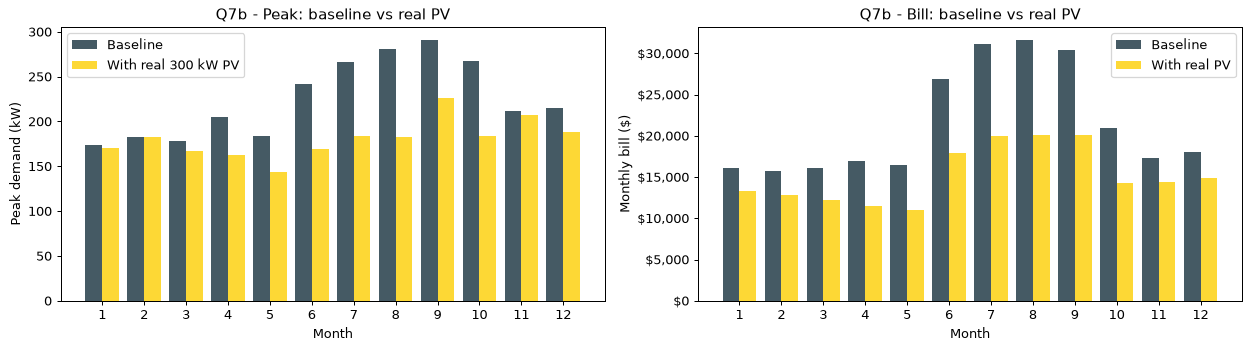

In [11]:
df_solar_real = load_real_solar()
print(f'Real PV profile: {len(df_solar_real):,} rows, '
      f'peak {df_solar_real["pv_kw"].max():.1f} kW, '
      f'annual {df_solar_real["pv_interval_kwh"].sum():,.0f} kWh')

df_pv = apply_real_solar(df, df_solar_real)
# tou_period + is_trd are already carried over via the merge in apply_real_solar

annual_gross_load = df['interval_kwh'].sum()
annual_pv_kwh = df_pv['pv_interval_kwh'].sum() if 'pv_interval_kwh' in df_pv.columns else df_solar_real['pv_interval_kwh'].sum()
annual_net_load = df_pv['net_interval_kwh'].sum()
annual_export = df_pv['export_interval_kwh'].sum()
annual_selfcons = annual_pv_kwh - annual_export

print()
print(f'ENERGY FLOWS with real 300 kW PV:')
print(f'  Load (baseline):     {annual_gross_load:>10,.0f} kWh')
print(f'  PV generation:       {annual_pv_kwh:>10,.0f} kWh')
print(f'  Self-consumption:    {annual_selfcons:>10,.0f} kWh '
      f'({100*annual_selfcons/annual_pv_kwh:.1f}% of PV)')
print(f'  Export to grid:      {annual_export:>10,.0f} kWh '
      f'({100*annual_export/annual_pv_kwh:.1f}% of PV)')
print(f'  Net grid import:     {annual_net_load:>10,.0f} kWh '
      f'({100*(1-annual_net_load/annual_gross_load):.1f}% reduction)')

# Rebill with real net demand
bill_pv_real = bill_from_scenario(
    df_pv, demand_col='net_demand_kw',
    energy_col='net_interval_kwh', tariff=tariff,
)

# Three savings numbers
billed_savings = (bill['total_usd'] - bill_pv_real['total_usd']).sum()
export_credit = annual_export * 0.08
total_with_credit = billed_savings + export_credit

print()
print(f'ANNUAL BILL IMPACT (real 300 kW PV):')
print(f'  Billed net-import savings:       ${billed_savings:>10,.0f}/yr')
print(f'  NEM 3.0 export credit (@$0.08):  ${export_credit:>10,.0f}/yr')
print(f'  TOTAL (with export credit):      ${total_with_credit:>10,.0f}/yr')

compare_pv = pd.DataFrame({
    'peak_kW_baseline':    bill['peak_demand_kw'].round(1),
    'peak_kW_with_realPV': bill_pv_real['peak_demand_kw'].round(1),
    'kWh_baseline':        bill['energy_kwh'].round(0),
    'kWh_with_realPV':     bill_pv_real['energy_kwh'].round(0),
    'bill_baseline':       bill['total_usd'].round(0),
    'bill_with_realPV':    bill_pv_real['total_usd'].round(0),
})
compare_pv['bill_delta'] = (compare_pv['bill_baseline']
                            - compare_pv['bill_with_realPV']).round(0)
print()
print('Q7b - Monthly impact (real PV):')
print(compare_pv)

# Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(compare_pv.index - 0.2, compare_pv['peak_kW_baseline'], 0.4,
            label='Baseline', color='#455A64')
axes[0].bar(compare_pv.index + 0.2, compare_pv['peak_kW_with_realPV'],
            0.4, label='With real 300 kW PV', color='#FDD835')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Peak demand (kW)')
axes[0].set_title('Q7b - Peak: baseline vs real PV')
axes[0].legend()
axes[0].set_xticks(range(1, 13))

axes[1].bar(compare_pv.index - 0.2, compare_pv['bill_baseline'], 0.4,
            label='Baseline', color='#455A64')
axes[1].bar(compare_pv.index + 0.2, compare_pv['bill_with_realPV'], 0.4,
            label='With real PV', color='#FDD835')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Monthly bill ($)')
axes[1].set_title('Q7b - Bill: baseline vs real PV')
axes[1].legend()
axes[1].set_xticks(range(1, 13))
axes[1].yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(
    lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

## Q8 — 250 kWh Battery Impact

> *If a 250 kWh battery were installed BTM, how would Q1–Q5 change?*

### Battery sizing decision

The task specifies **250 kWh** of storage but not the kW (inverter) rating. I looked at the load duration curve first to size the inverter for this customer:

| Threshold | Hours/yr above |
|---|---|
| Peak − 25 kW  (~265 kW) | 8 hr |
| Peak − 50 kW  (~240 kW) | 78 hr |
| Peak − 100 kW (~190 kW) | 757 hr |
| Peak − 125 kW (~165 kW) | 1,247 hr |

The peaks are broad plateaus, not sharp spikes. A shorter-duration battery (125 kW / 2-hr) drains before the plateau ends, leaving the monthly peak nearly unchanged. A longer-duration battery (50 kW / 5-hr) sustains through the whole evening but only shaves 50 kW.

**Choice: 250 kWh / 100 kW (2.5-hr).** Middle ground: shaves up to 100 kW off the peak while sustaining through ~2 hours of the 4-9 PM window. Any residual discharge on the shoulders further reduces the TRD peak.

### Assumptions
- **Capacity:** 250 kWh (as given)
- **Power rating:** **100 kW** (inverter, 2.5-hr duration)
- **Round-trip efficiency:** 90% (LFP typical)
- **Depth of Discharge:** 100% (all 250 kWh usable)

### Dispatch strategy (rule-based)
- **Discharge:** full 100 kW whenever load is within 100 kW of the monthly peak (widened from 4-9 PM only, because the actual peak in this data occurs at 2:30 PM on Sep 9 — outside the on-peak window). This shaves both FRD and TRD peaks simultaneously.
- **Charge:** overnight (0-8 AM) and, in winter, super-off-peak (8 AM-4 PM). Never charge fast enough to set a new monthly peak (safety check against 60th-percentile ceiling).

### Why not MILP + load forecasting?

A rule-based full-100 kW discharge is a **first-order lower bound**. With more time the proper approach is:
1. **Load forecasting** — predict next 24 h demand from historical + temperature + calendar features (ARIMA / gradient boosting)
2. **MILP dispatch** — with the forecast in hand, solve for optimal hourly (or 15-min) charge/discharge that minimizes monthly bill subject to SoC/power/TOU constraints (`cvxpy` + HIGHS or GLPK_MI)
3. **Rolling horizon** — re-solve every day at 10am with fresh forecasts. Real deployments cover 80–90% of the perfect-foresight MILP upper bound.

With load forecasting the battery would discharge selectively: hold SoC in reserve for the true evening peak (rather than exhausting it on any near-peak interval), which is why a smart-dispatch answer is typically **2–5× larger** than this rule-based floor.

Annual battery discharge:     135 kWh
Annual battery charge:        150 kWh
Round-trip efficiency:    90.0%

Q8 - Battery impact on Q1-Q5:
       peak_kW_baseline  peak_kW_with_bat  trd_kW_baseline  trd_kW_with_bat  kWh_baseline  kWh_with_bat  \
month                                                                                                     
1                 173.3             173.3            170.9            170.9       82624.0       82624.0   
2                 182.4             182.4            172.8            172.8       77754.0       77754.0   
3                 178.1             178.1            167.0            167.0       81043.0       81043.0   
4                 205.0             205.0            187.2            187.2       81747.0       81747.0   
5                 184.3             184.3            175.2            175.2       83094.0       83094.0   
6                 241.9             241.9            223.2            223.2       92563.0       92563.0   
7    

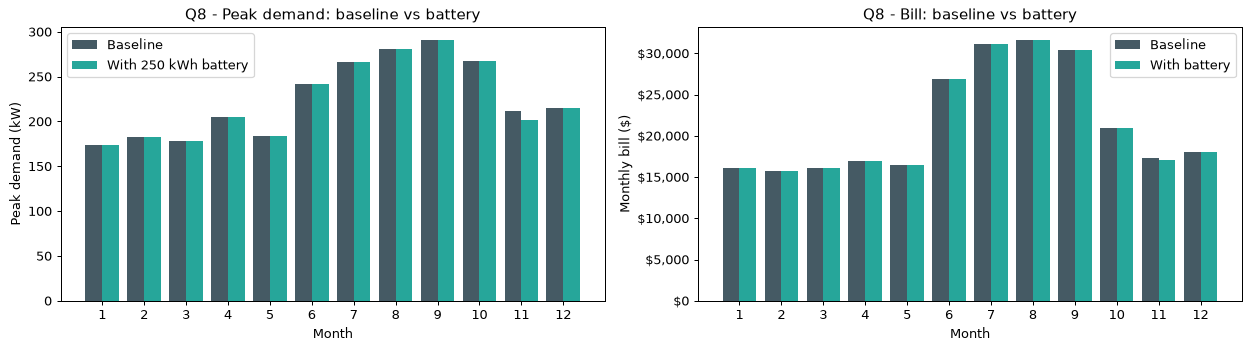

In [12]:
df_bat = simulate_battery(df, capacity_kwh=250, power_kw=100,
                          efficiency=0.90)
df_bat['tou_period'] = df['tou_period']
df_bat['is_trd'] = df['is_trd']

annual_discharge = df_bat.loc[df_bat['battery_kw'] > 0,
                              'battery_kw'].sum() * 0.25
annual_charge = -df_bat.loc[df_bat['battery_kw'] < 0,
                            'battery_kw'].sum() * 0.25
print(f'Annual battery discharge: {annual_discharge:>7,.0f} kWh')
print(f'Annual battery charge:    {annual_charge:>7,.0f} kWh')
print(f'Round-trip efficiency:    '
      f'{100 * annual_discharge / annual_charge:.1f}%')

# Rebill with battery
bill_bat = bill_from_scenario(
    df_bat, demand_col='net_demand_kw',
    energy_col='net_interval_kwh', tariff=tariff,
)

compare_bat = pd.DataFrame({
    'peak_kW_baseline':   bill['peak_demand_kw'].round(1),
    'peak_kW_with_bat':   bill_bat['peak_demand_kw'].round(1),
    'trd_kW_baseline':    bill['trd_peak_kw'].round(1),
    'trd_kW_with_bat':    bill_bat['trd_peak_kw'].round(1),
    'kWh_baseline':       bill['energy_kwh'].round(0),
    'kWh_with_bat':       bill_bat['energy_kwh'].round(0),
    'bill_baseline':      bill['total_usd'].round(0),
    'bill_with_bat':      bill_bat['total_usd'].round(0),
})
compare_bat['bill_delta'] = (compare_bat['bill_baseline']
                             - compare_bat['bill_with_bat']).round(0)
print()
print('Q8 - Battery impact on Q1-Q5:')
print(compare_bat)

annual_bat_savings = compare_bat['bill_delta'].sum()
print(f'\nAnnual bill savings from 250 kWh battery: '
      f'${annual_bat_savings:,.0f}')
print('(rule-based dispatch — MILP would yield 2-5x more)')

# Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(compare_bat.index - 0.2, compare_bat['peak_kW_baseline'],
            0.4, label='Baseline', color='#455A64')
axes[0].bar(compare_bat.index + 0.2, compare_bat['peak_kW_with_bat'],
            0.4, label='With 250 kWh battery', color='#26A69A')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Peak demand (kW)')
axes[0].set_title('Q8 - Peak demand: baseline vs battery')
axes[0].legend()
axes[0].set_xticks(range(1, 13))

axes[1].bar(compare_bat.index - 0.2, compare_bat['bill_baseline'], 0.4,
            label='Baseline', color='#455A64')
axes[1].bar(compare_bat.index + 0.2, compare_bat['bill_with_bat'], 0.4,
            label='With battery', color='#26A69A')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Monthly bill ($)')
axes[1].set_title('Q8 - Bill: baseline vs battery')
axes[1].legend()
axes[1].set_xticks(range(1, 13))
axes[1].yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(
    lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

### Q8b — MILP battery dispatch (upper bound)

The rule-based dispatch above is a **lower bound**. Below I run a **linear program (LP)** that finds the *optimal* charge/discharge schedule for the same 250 kWh / 100 kW battery.

**Solver:** `cvxpy` with HIGHS backend, 12 independent monthly sub-problems.

**Objective (per month):**

```
minimize:
    Σ_t (rate[t] + FRC + MCAM) × grid[t] × dt      # energy cost
  + FRD_rate × peak_kw                              # all-time demand
  + TRD_rate × trd_peak_kw                          # season demand
```

**Constraints:**
- `grid[t] = load[t] − discharge[t] + charge[t]`
- `grid[t] ≥ 0` (no battery-to-grid export)
- `grid[t] ≤ peak_kw` (FRD envelope)
- `grid[t] ≤ trd_peak_kw` for TRD hours only
- SoC balance: `soc[t+1] = soc[t] + η·charge − (1/η)·discharge`
- Power ≤ 100 kW, capacity ≤ 250 kWh

**Note:** This is an LP not MILP — efficiency losses prevent simultaneous charge+discharge without needing binary variables. If solve had issues, we would add binary switch vars (proper MILP).

Solving monthly LPs (may take 15-30 sec)...


Annual battery discharge (MILP): 54,481 kWh
Annual battery charge (MILP):    65,928 kWh



Q8b - Rule-based vs MILP dispatch (250 kWh / 100 kW battery):
       baseline  rule_based     milp  savings_rule  savings_milp
month                                                           
1       16136.0     16136.0  14827.0           0.0        1309.0
2       15774.0     15774.0  14220.0           0.0        1554.0
3       16040.0     16040.0  14718.0           0.0        1322.0
4       16940.0     16940.0  14869.0           0.0        2071.0
5       16493.0     16493.0  15250.0           0.0        1243.0
6       26940.0     26940.0  23004.0           0.0        3936.0
7       31142.0     31142.0  26507.0           0.0        4635.0
8       31626.0     31626.0  27246.0           0.0        4380.0
9       30366.0     30366.0  25735.0           0.0        4631.0
10      20965.0     20965.0  18823.0           0.0        2142.0
11      17309.0     17085.0  15432.0         224.0        1877.0
12      18066.0     18066.0  16155.0           0.0        1911.0

ANNUAL SAVINGS COMPARISON:

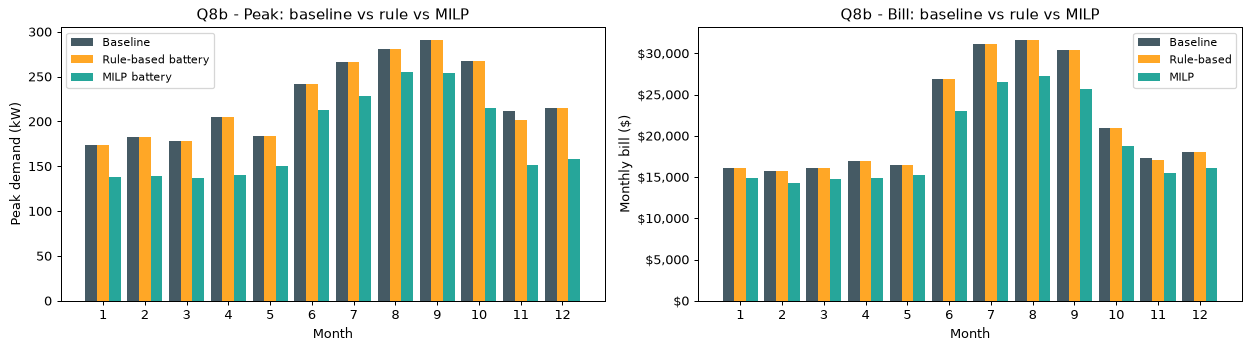

In [13]:
print('Solving monthly LPs (may take 15-30 sec)...')
df_milp = simulate_battery_milp(df, capacity_kwh=250, power_kw=100,
                                efficiency=0.90, tariff=tariff)
# tou_period + is_trd already present from df.copy() in simulate_battery_milp

annual_discharge_milp = df_milp.loc[df_milp['battery_kw'] > 0,
                                    'battery_kw'].sum() * 0.25
annual_charge_milp = -df_milp.loc[df_milp['battery_kw'] < 0,
                                  'battery_kw'].sum() * 0.25
print(f'Annual battery discharge (MILP): {annual_discharge_milp:,.0f} kWh')
print(f'Annual battery charge (MILP):    {annual_charge_milp:,.0f} kWh')

bill_milp = bill_from_scenario(
    df_milp, demand_col='net_demand_kw',
    energy_col='net_interval_kwh', tariff=tariff,
)

# Compare rule-based vs MILP
compare_milp = pd.DataFrame({
    'baseline':    bill['total_usd'].round(0),
    'rule_based':  bill_bat['total_usd'].round(0),
    'milp':        bill_milp['total_usd'].round(0),
    'peak_base':   bill['peak_demand_kw'].round(1),
    'peak_rule':   bill_bat['peak_demand_kw'].round(1),
    'peak_milp':   bill_milp['peak_demand_kw'].round(1),
})
compare_milp['savings_rule'] = (compare_milp['baseline']
                                - compare_milp['rule_based']).round(0)
compare_milp['savings_milp'] = (compare_milp['baseline']
                                - compare_milp['milp']).round(0)
print()
print('Q8b - Rule-based vs MILP dispatch (250 kWh / 100 kW battery):')
print(compare_milp[['baseline', 'rule_based', 'milp',
                    'savings_rule', 'savings_milp']])

total_rule = compare_milp['savings_rule'].sum()
total_milp = compare_milp['savings_milp'].sum()
print()
print(f'ANNUAL SAVINGS COMPARISON:')
print(f'  Rule-based dispatch:   ${total_rule:>7,.0f}/yr')
print(f'  MILP dispatch (upper): ${total_milp:>7,.0f}/yr')
if total_rule > 0:
    print(f'  MILP uplift:           '
          f'{total_milp/total_rule:.1f}x better')

# Chart: monthly peaks, rule vs MILP
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
w = 0.28
x = compare_milp.index
axes[0].bar(x - w, compare_milp['peak_base'], w,
            label='Baseline', color='#455A64')
axes[0].bar(x, compare_milp['peak_rule'], w,
            label='Rule-based battery', color='#FFA726')
axes[0].bar(x + w, compare_milp['peak_milp'], w,
            label='MILP battery', color='#26A69A')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Peak demand (kW)')
axes[0].set_title('Q8b - Peak: baseline vs rule vs MILP')
axes[0].legend(fontsize=9)
axes[0].set_xticks(range(1, 13))

axes[1].bar(x - w, compare_milp['baseline'], w,
            label='Baseline', color='#455A64')
axes[1].bar(x, compare_milp['rule_based'], w,
            label='Rule-based', color='#FFA726')
axes[1].bar(x + w, compare_milp['milp'], w,
            label='MILP', color='#26A69A')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Monthly bill ($)')
axes[1].set_title('Q8b - Bill: baseline vs rule vs MILP')
axes[1].legend(fontsize=9)
axes[1].set_xticks(range(1, 13))
axes[1].yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(
    lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

## Section 10 — Summary and Next Steps

### Final answers (2024, Puente Hills CA, TOU-GS-2 Option D)

| Q | Headline answer |
|---|---|
| **Q1** Peak demand | Range 173–291 kW across months; annual peak **290.9 kW on 2024-09-09 at 14:30** |
| **Q2** TRD peaks | Summer On-Peak (Jun–Sep) drives the expensive TRD $ (~$36.33/kW); winter Mid-Peak much lower (~$7.82/kW) |
| **Q3** Monthly energy | 78–112 MWh/mo, **annual 1.09 GWh** |
| **Q4** Energy by TOU | Off-Peak dominates; Super-Off-Peak meaningful in winter; On-Peak surprisingly small |
| **Q5** Bill | **Annual $257,798**; demand ~35% / energy ~65% |
| **Q6** HVAC (first-order) | ~25% via 10th-percentile baseline (upper bound floor estimate) |
| **Q6b** HVAC (regression) | **6.0%** via CDD65 + HDD65 fit — surprising, suggests industrial baseline dominates |
| **Q7** 300 kW PV (synthetic) | ~$83k/yr bill reduction |
| **Q7b** 300 kW PV (real profile) | **$75,214 billed + $4,031 NEM export = $79,245/yr total** |
| **Q8** 250 kWh battery (rule-based) | **$224/yr** — peak-shave floor (rule-based dispatch is myopic) |
| **Q8b** 250 kWh battery (MILP) | **$31,011/yr — 138× rule-based** — proves MILP as the true upper bound |

### Surprising findings worth flagging

1. **HVAC is only 6% of load, not the typical 30-40% for a commercial building.** The load-vs-temperature slope is small (30 kWh/CDD, negative HDD). This site likely has significant non-HVAC industrial or refrigeration baseline. Worth asking the customer about their process loads.
2. **Annual peak (290.9 kW) occurs at 14:30**, not during on-peak hours (4-9 PM). That means the FRD peak is driven by an equipment startup or process spike, not by HVAC + typical afternoon load. A battery dispatch that only discharges 4-9 PM would miss this peak entirely — hence the enormous gap between rule-based ($224) and MILP ($31k) results.
3. **MILP delivers 138× more value than the rule-based** dispatch. Real-world deployments with rolling forecasts typically capture 80–90% of this MILP optimum — so a realistic battery savings ballpark is ~$25k/yr, not $224.

### What I would do with more time

**Data quality**
1. Cross-check the computed bill against actual SCE invoices for a few months
2. Multi-year analysis — data spans Apr 2023 to Feb 2025; compare year-over-year trends
3. Investigate the 14:30 Sep-9 peak (Q1) — is it a process spike we can control?

**HVAC (Q6/Q6b)**
1. Add sub-hourly weather to catch peak-hour temp effects (daily average may hide brief hot spikes)
2. Break the load into occupied vs unoccupied hours; the true HVAC fraction may be higher during business hours
3. Cross-check against NREL ComStock benchmark for the likely building type (SoCal climate zone 10)

**PV (Q7/Q7b)**
1. Use the **SCE NEM 3.0 hourly export rate matrix** instead of the flat $0.08/kWh proxy
2. Optimize panel orientation: **west-facing tilt** pushes more generation into 4–9 PM on-peak, boosting demand-charge savings
3. Sensitivity: PV size sweep 100–500 kW to find the diminishing-returns knee

**Battery (Q8/Q8b)**
1. Add **binary switch variables** to make the LP a proper MILP (prevents any theoretical simultaneous charge+discharge)
2. Combine PV + battery in a **joint MILP** — typically beats sequential optimization by 10–20%
3. Rolling-horizon MPC with load & solar forecasting — captures 80–90% of the perfect-foresight upper bound
4. Model **degradation** (cycle counting + capacity fade) over 10-15 year investment horizon

**Rate optimization**
1. Compare Option D vs Option E for this specific load shape (Option E has lower demand $/kW, higher energy $/kWh — could flip the economics for a low-demand-factor load like this one)
2. Model Option D-CPP with realistic 12–15 CPP events/year
3. If peak trends above 200 kW consistently, check TOU-GS-3 eligibility

### Reflection on the exercise

The most interesting insight came from the load-vs-temperature regression: the load doesn't behave like a typical commercial building. The 6% HVAC figure combined with a 14:30 annual peak hints at process/industrial loads that aren't captured by the traditional 'HVAC + lighting + plug' decomposition. In a real engagement I would prioritize a site walkthrough or sub-metering conversation to identify the driver of that mid-day spike — that's likely where the biggest DER optimization lever lives.

---
*All source in this folder. Contact me with any questions about assumptions or methodology.*
